In [117]:
import numpy as np
import matplotlib.pyplot as plt

import fit_force
import physics_model

In [219]:
class DummyForce(physics_model.TorqueLeverSimulation):
    def __init__(self):
        tt = np.linspace(0, 1, 500)
        super().__init__(lever_mass = 3.5e-3,    #kg
                         lever_length = 15e-2,   #meter
                         lever_range = (30, 100), #degrees
                         motor_baseline_torque = 3e-3,
                         motor_extra_torque = 2e-2,
                         motor_onset_angle = (75, 80),
                         friction_coeff = 0.0e-3,
                         dt=1e-3)
        self.dummy_force = -np.sin(4*tt)**2*tt - 0.1*tt**2
    
    def get_torque_rat(self):
        force = self.dummy_force[int(self.time / self.dt)]
        torque = force * self.lever_length * np.sin(self.theta) / 2
        return torque

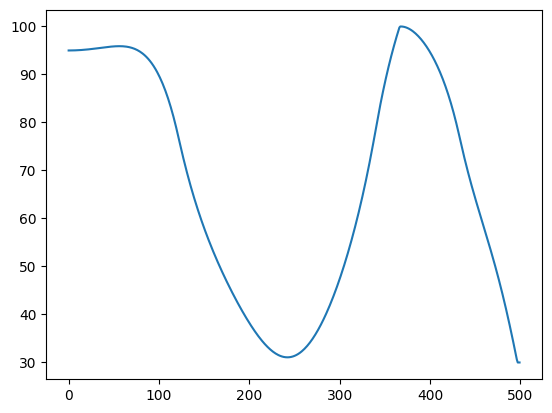

In [220]:
res = DummyForce().simulate_trial(duration=0.5)
dummy_theta = res["theta"]
plt.plot(np.rad2deg(dummy_theta))

In [221]:
import jax
import jax.numpy as jp
import importlib

In [279]:
importlib.reload(fit_force)

<module 'fit_force' from '/home/emil/Development/torque_lever_modelling/fit_force.py'>

In [280]:
jax_simulation = fit_force.TorqueLeverSimulationJAX(lever_mass = 3.5e-3,    #kg
                         lever_length = 15e-2,   #meter
                         lever_range = (30, 100), #degrees
                         motor_baseline_torque = 3e-3,
                         motor_extra_torque = 2e-2,
                         motor_onset_angle = (75, 80),
                         autoregressive_penalty=1e3,
                         friction_coeff = 0.0e-3,
                         dt=1e-3)

In [282]:
df = DummyForce()
true_theta_0 = df.lever_max - np.deg2rad(5)
true_theta_dot_0 = 0.0
true_cand = (jp.array(DummyForce().dummy_force), [true_theta_0], [true_theta_dot_0])
loss, _ = jax_simulation.eval_candidate(true_cand, jp.array(dummy_theta))
loss

Array(-0.01349757, dtype=float32)

In [283]:
noise = jax.random.normal(jax.random.key(123), true_cand[0].shape)
start_candidate = (
    jp.linspace(0, -0.5, dummy_theta.shape[0]),#true_cand[0] + 0.0*noise - 0.2,
    true_cand[1],
    true_cand[2],
)

In [285]:
losses, candidate, theta = jax_simulation.fit_force(jp.array(dummy_theta), n_steps=10, start_candidate=start_candidate)

AttributeError: 'float' object has no attribute 'shape'

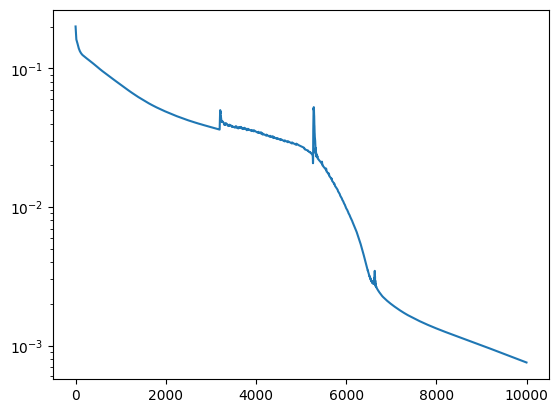

In [270]:
plt.semilogy(-losses)
#plt.ylim(0, 0.5)

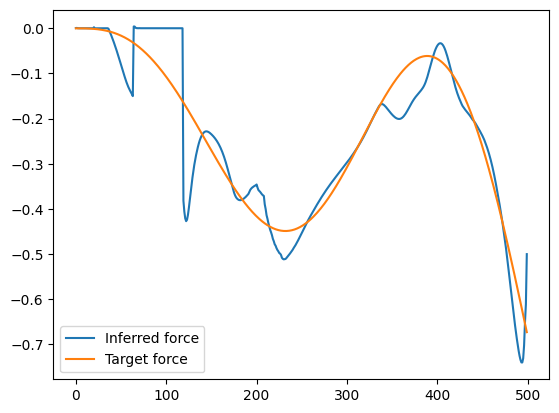

In [271]:
plt.plot(candidate[0], label="Inferred force")
plt.plot(DummyForce().dummy_force, label="Target force")
plt.legend()

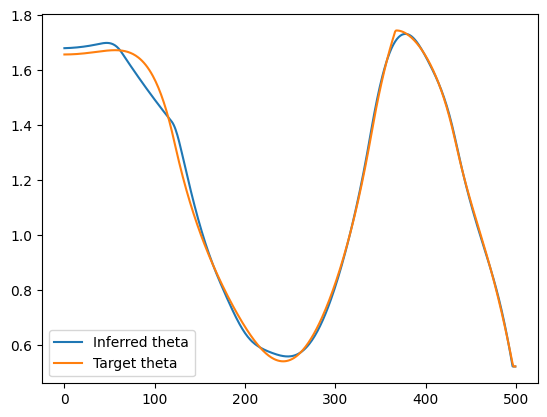

In [272]:
plt.plot(theta, label="Inferred theta")
plt.plot(dummy_theta, label="Target theta")
plt.legend()